In [1]:
"""
splitcode, version 0.30.0

config for splitcode 
@extract <13Gumi[10]>8{{group2}},<13Gbc[8]>{{group2}},{{group2}}<13Gbc[8]>{{group1}},{{group1}}<13Gbc[8]>,{{group1}}8<13Gread>0:-1
@extract <13Gfbc[8]>{{group1}},{{group1}}<13Gfbc[8]>,{{group2}}<13Gfbc[8]>,{{group2}}8<13Gfumi[10]>,0:0<13Gfread>14{{group1}}
groups	ids	tags	distances	locations
group1	linker1	CCACAGTCTCAAGCACGTGGAT	3:3:3	0:0:0
group1	linker1rc	ATCCACGTGCTTGAGACTGTGG	3:3:3	0:0:0
group1	linker1r	TAGGTGCACGAACTCTGACACC	3:3:3	0:0:0
group1	linker1rcr	GGTGTCAGAGTTCGTGCACCTA	3:3:3	0:0:0
group2	linker2	AGTCGTACGCCGATGCGAAACATCGGCCAC	3:3:3	0:0:0
group2	linker2rc	GTGGCCGATGTTTCGCATCGGCGTACGACT	3:3:3	0:0:0
group2	linker2r	CACCGGCTACAAAGCGTAGCCGCATGCTGA	3:3:3	0:0:0
group2	linker2rcr	TCAGCATGCGGCTACGCTTTGTAGCCGGTG	3:3:3	0:0:0

splitcode/build/src/splitcode -c config.txt igvfb01_13G-gc_lig-ss_11.fastq.gz -o igvfb01_13G_scmodified/igvfb01_13G_lig-ss.fastq.gz

cat 13Gumi.fastq.gz  13Gfumi.fastq.gz > 13G_umi.fastq.gz
cat 13Gbc.fastq.gz  13Gfbc.fastq.gz > 13G_bc.fastq.gz
cat 13Gread.fastq.gz  13Gfread.fastq.gz > 13G_read.fastq.gz

ref='ref/mm39'
tech='2,0,24:1,0,10:0,0,0'
#kb ref --kallisto ${path_to_lr_kallisto} -i ${ref}_k-63.idx -k 63 -f1 ${ref}.cdna.fa -g ${ref}.t2g ${ref}.fa.gz ${ref}.gtf.gz 
sample='13G_'
output='b01_nanopore_'${sample}'_sc_single_cell'

kallisto bus -x ${tech} --long -i ${ref}_k-63.idx -o ${output} -t 32 ${sample}read.fastq.gz ${sample}umi.fastq.gz ${sample}bc.fastq.gz

${path_to_bustools} sort -t 32 ${output}/output.bus \
 -o ${output}/sorted.bus; \
 ${path_to_bustools} whitelist --threshold 200 -o ${output}/whitelist.txt \
 ${output}/sorted.bus; \
 ${path_to_bustools} correct -w ${output}/whitelist.txt \
 -o ${output}/corrected.bus ${output}/sorted.bus; \ 
 ${path_to_bustools} capture -b -c ${output}/whitelist.txt \
 -o ${output}/captured.bus ${output}/corrected.bus; \
 ${path_to_bustools} count ${output}/captured.bus \
 -t ${output}/transcripts.txt \
 -e ${output}/matrix.ec \
 -o ${output}/count -m \
 -g ${ref}.t2g; \
 ${path_to_lr_kallisto} quant-tcc -t 32 \
 ${output}/count.mtx \
 -i ${ref}_k-63.idx \
 -f ${output}/flens.txt \
 -e ${output}/count.ec.txt \
 -o ${output};

 ${path_to_bustools} count ${output}/corrected.bus \
 -t ${output}/transcripts.txt \
 -e ${output}/matrix.ec \
 -o ${output}/gcount --em --genecounts \
 -g ${ref}.t2g;
"""

"\nsplitcode, version 0.30.0\n\nconfig for splitcode \n@extract <13Gumi[10]>8{{group2}},<13Gbc[8]>{{group2}},{{group2}}<13Gbc[8]>{{group1}},{{group1}}<13Gbc[8]>,{{group1}}8<13Gread>0:-1\n@extract <13Gfbc[8]>{{group1}},{{group1}}<13Gfbc[8]>,{{group2}}<13Gfbc[8]>,{{group2}}8<13Gfumi[10]>,0:0<13Gfread>14{{group1}}\ngroups\tids\ttags\tdistances\tlocations\ngroup1\tlinker1\tCCACAGTCTCAAGCACGTGGAT\t3:3:3\t0:0:0\ngroup1\tlinker1rc\tATCCACGTGCTTGAGACTGTGG\t3:3:3\t0:0:0\ngroup1\tlinker1r\tTAGGTGCACGAACTCTGACACC\t3:3:3\t0:0:0\ngroup1\tlinker1rcr\tGGTGTCAGAGTTCGTGCACCTA\t3:3:3\t0:0:0\ngroup2\tlinker2\tAGTCGTACGCCGATGCGAAACATCGGCCAC\t3:3:3\t0:0:0\ngroup2\tlinker2rc\tGTGGCCGATGTTTCGCATCGGCGTACGACT\t3:3:3\t0:0:0\ngroup2\tlinker2r\tCACCGGCTACAAAGCGTAGCCGCATGCTGA\t3:3:3\t0:0:0\ngroup2\tlinker2rcr\tTCAGCATGCGGCTACGCTTTGTAGCCGGTG\t3:3:3\t0:0:0\n\nsplitcode/build/src/splitcode -c config.txt igvfb01_13G-gc_lig-ss_11.fastq.gz -o igvfb01_13G_scmodified/igvfb01_13G_lig-ss.fastq.gz\n\ncat 13Gumi.fastq.gz  13G

In [2]:
# Import packages
import scipy
import anndata
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from sklearn.decomposition import TruncatedSVD
from scipy import sparse, io
import seaborn as sns

matplotlib.rcParams.update({'font.size': 12})
%config InlineBackend.figure_format = 'retina'


In [3]:
dir_IlluminaO = '13G_diane/b01_nanopore_13G_single_cell_k63_randO_mm39/counts_unfiltered/cells_x_genes'
#'13G_single_cell/b01_nanopore_13G_single_cell_randO/counts_unfiltered/cells_x_genes'
Oadata = sc.read_mtx(dir_IlluminaO+".mtx")
Oadata.obs.index = pd.read_csv(dir_IlluminaO+".barcodes.txt", header=None)[0].values
Oadata.var.index = pd.read_csv(dir_IlluminaO+".genes.txt", header=None)[0].values

dir_IlluminaT = '13G_diane/b01_nanopore_13G_single_cell_k63_polyT_mm39/counts_unfiltered/cells_x_genes'
#'13G_single_cell/b01_nanopore_13G_single_cell_polyT/counts_unfiltered/cells_x_genes'
Tadata = sc.read_mtx(dir_IlluminaT+".mtx")
Tadata.obs.index = pd.read_csv(dir_IlluminaT+".barcodes.txt", header=None)[0].values
Tadata.var.index = pd.read_csv(dir_IlluminaT+".genes.txt", header=None)[0].values

In [4]:
Tadata.obs.index

Index(['AAACATCGAACAACCAATTTGGCA', 'AAACATCGAACTCACCTCATTGCA',
       'AAACATCGAACTCACCTCTCATGC', 'AAACATCGAAGAGATCTCATTGCA',
       'AAACATCGAAGGTACACATGTCTC', 'AAACATCGAATCCGTCACTGCTCT',
       'AAACATCGAATCCGTCCTTCTAAC', 'AAACATCGAATCCGTCTCTCATGC',
       'AAACATCGAATGTTGCCCAATTCT', 'AAACATCGACAAGCTAGCTATCAT',
       ...
       'TTCACGCAGTCTGTCATTATTCTG', 'TTCACGCATAGGATGAATCCTTAC',
       'TTCACGCATATCAGCACATACTTC', 'TTCACGCATCCGTCTACCGTTCTA',
       'TTCACGCATCCGTCTATAAATATC', 'TTCACGCATCTTCACAGCTATCAT',
       'TTCACGCATCTTCACATTATTCTG', 'TTCACGCATGAAGAGAATCCTTAC',
       'TTCACGCATGGTGGTAACATTTAC', 'TTCACGCATGGTGGTAGCTTCATA'],
      dtype='object', length=11206)

In [5]:
Oadata.obs.index

Index(['AAACATCGAACAACCAATTTGGCA', 'AAACATCGAACTCACCTCATTGCA',
       'AAACATCGAACTCACCTCTCATGC', 'AAACATCGAAGAGATCTCATTGCA',
       'AAACATCGAAGGTACACATGTCTC', 'AAACATCGAATCCGTCACTGCTCT',
       'AAACATCGAATCCGTCCTTCTAAC', 'AAACATCGAATCCGTCTCTCATGC',
       'AAACATCGAATGTTGCCCAATTCT', 'AAACATCGACAAGCTAGCTATCAT',
       ...
       'TTCACGCAGTCTGTCATTATTCTG', 'TTCACGCATAGGATGAATCCTTAC',
       'TTCACGCATATCAGCACATACTTC', 'TTCACGCATCCGTCTACCGTTCTA',
       'TTCACGCATCCGTCTATAAATATC', 'TTCACGCATCTTCACAGCTATCAT',
       'TTCACGCATCTTCACATTATTCTG', 'TTCACGCATGAAGAGAATCCTTAC',
       'TTCACGCATGGTGGTAACATTTAC', 'TTCACGCATGGTGGTAGCTTCATA'],
      dtype='object', length=11206)

In [6]:
#Tadata.obs.index=[t[16:24]+t[8:16]+t[0:8] for t in Tadata.obs.index]
#Oadata.obs.index=[t[16:24]+t[8:16]+t[0:8] for t in Oadata.obs.index]

In [7]:
import os
barcodes_prefix_path = os.path.join(dir_IlluminaO+'.barcodes.txt')
# add barcode prefix
with open(barcodes_prefix_path) as f:
    print("opening")
    bc_prefix = f.read().splitlines()
Oadata.obs["barcode"] = Oadata.obs.index.values
Oadata.obs["libcode"] = bc_prefix
Oadata.obs["iden_bc"] = Oadata.obs.index.str[16:24]
Oadata.obs["barcode_idx"] = Oadata.obs["libcode"] + Oadata.obs["barcode"]
Oadata.obs.index = Oadata.obs["barcode_idx"]
# load in metadata
meta_path="plate01.txt"
metadata = pd.read_csv(meta_path,sep='\t', header=0)
# create well to barcode from metadata
wells_x_2 = list(metadata['well'])*2
sequence = list(metadata['t_bc']) + list(metadata['r_bc'])
barcode_type = ['T']*96 + ['R']*96
bc2well = pd.DataFrame({'well' : wells_x_2, 'sequence' : sequence, 'type' : barcode_type})
# add metadata to adata obs
Oadata.obs = Oadata.obs.merge(bc2well, left_on="iden_bc", right_on="sequence", how="left").set_index("barcode_idx", drop=False)
# add tissue, sex, strain metadata
# metadata_no_bc = metadata.drop([‘t_bc’,‘r_bc’],axis = 1)
Oadata.obs = Oadata.obs.merge(metadata,
                            left_on="well",
                            right_on="well",
                            how="left").set_index("barcode_idx", drop=False)
Oadata.obs["cell_identity"] = Oadata.obs.index.str[0:16] + '-' + Oadata.obs.well
Oadata.obs.index = Oadata.obs["cell_identity"]

opening


In [8]:
import os
barcodes_prefix_path = os.path.join(dir_IlluminaT+'.barcodes.txt')
# add barcode prefix
with open(barcodes_prefix_path) as f:
    print("opening")
    bc_prefix = f.read().splitlines()
Tadata.obs["barcode"] = Tadata.obs.index.values
Tadata.obs["libcode"] = bc_prefix
Tadata.obs["iden_bc"] = Tadata.obs.index.str[16:24]
Tadata.obs["barcode_idx"] = Tadata.obs["libcode"] + Tadata.obs["barcode"]
Tadata.obs.index = Tadata.obs["barcode_idx"]
# load in metadata
meta_path="plate01.txt"
metadata = pd.read_csv(meta_path,sep='\t', header=0)
# create well to barcode from metadata
wells_x_2 = list(metadata['well'])*2
sequence = list(metadata['t_bc']) + list(metadata['r_bc'])
barcode_type = ['T']*96 + ['R']*96
bc2well = pd.DataFrame({'well' : wells_x_2, 'sequence' : sequence, 'type' : barcode_type})
# add metadata to adata obs
Tadata.obs = Tadata.obs.merge(bc2well, left_on="iden_bc", right_on="sequence", how="left").set_index("barcode_idx", drop=False)
# add tissue, sex, strain metadata
# metadata_no_bc = metadata.drop([‘t_bc’,‘r_bc’],axis = 1)
Tadata.obs = Tadata.obs.merge(metadata,
                            left_on="well",
                            right_on="well",
                            how="left").set_index("barcode_idx", drop=False)
Tadata.obs["cell_identity"] = Tadata.obs.index.str[0:16] + '-' + Tadata.obs.well
Tadata.obs.index = Tadata.obs["cell_identity"]

opening


In [9]:
Oadata.var

""
ENSMUSG00000102693.2
ENSMUSG00000064842.3
ENSMUSG00000051951.6
ENSMUSG00000102851.2
ENSMUSG00000103377.2
...
ENSMUSG00000095366.3
ENSMUSG00000095134.3
ENSMUSG00000096768.9
ENSMUSG00000099871.2


In [10]:
Tadata.var

""
ENSMUSG00000102693.2
ENSMUSG00000064842.3
ENSMUSG00000051951.6
ENSMUSG00000102851.2
ENSMUSG00000103377.2
...
ENSMUSG00000095366.3
ENSMUSG00000095134.3
ENSMUSG00000096768.9
ENSMUSG00000099871.2


In [11]:
Tadata.obs

,barcode,libcode,iden_bc,barcode_idx,well,sequence,type,t_bc,r_bc,sex,rep,strain,sample,cell_identity
cell_identity,,,,,,,,,,,,,,
AAACATCGAACAACCA-B1,AAACATCGAACAACCAATTTGGCA,AAACATCGAACAACCAATTTGGCA,ATTTGGCA,AAACATCGAACAACCAATTTGGCAAAACATCGAACAACCAATTTGGCA,B1,ATTTGGCA,T,ATTTGGCA,TATGTGTC,F,1,NODShiLtJ,CortexHippocampus,AAACATCGAACAACCA-B1
AAACATCGAACTCACC-C2,AAACATCGAACTCACCTCATTGCA,AAACATCGAACTCACCTCATTGCA,TCATTGCA,AAACATCGAACTCACCTCATTGCAAAACATCGAACTCACCTCATTGCA,C2,TCATTGCA,T,TCATTGCA,TAGTTTCC,M,1,AJ,CortexHippocampus,AAACATCGAACTCACC-C2
AAACATCGAACTCACC-C9,AAACATCGAACTCACCTCTCATGC,AAACATCGAACTCACCTCTCATGC,TCTCATGC,AAACATCGAACTCACCTCTCATGCAAACATCGAACTCACCTCTCATGC,C9,TCTCATGC,T,TCTCATGC,CCATCTTG,F,1,AJ/PWKPhJ,Heart,AAACATCGAACTCACC-C9
AAACATCGAAGAGATC-C2,AAACATCGAAGAGATCTCATTGCA,AAACATCGAAGAGATCTCATTGCA,TCATTGCA,AAACATCGAAGAGATCTCATTGCAAAACATCGAAGAGATCTCATTGCA,C2,TCATTGCA,T,TCATTGCA,TAGTTTCC,M,1,AJ,CortexHippocampus,AAACATCGAAGAGATC-C2
AAACATCGAAGGTACA-C1,AAACATCGAAGGTACACATGTCTC,AAACATCGAAGGTACACATGTCTC,CATGTCTC,AAACATCGAAGGTACACATGTCTCAAACATCGAAGGTACACATGTCTC,C1,CATGTCTC,T,CATGTCTC,GCTATCTC,F,1,AJ,CortexHippocampus,AAACATCGAAGGTACA-C1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTCACGCATCTTCACA-D9,TTCACGCATCTTCACAGCTATCAT,TTCACGCATCTTCACAGCTATCAT,GCTATCAT,TTCACGCATCTTCACAGCTATCATTTCACGCATCTTCACAGCTATCAT,D9,GCTATCAT,T,GCTATCAT,GTGCTTGA,F,3,AJ/PWKPhJ,Heart,TTCACGCATCTTCACA-D9
TTCACGCATCTTCACA-B2,TTCACGCATCTTCACATTATTCTG,TTCACGCATCTTCACATTATTCTG,TTATTCTG,TTCACGCATCTTCACATTATTCTGTTCACGCATCTTCACATTATTCTG,B2,TTATTCTG,T,TTATTCTG,CAATTCTC,M,1,NODShiLtJ,CortexHippocampus,TTCACGCATCTTCACA-B2
TTCACGCATGAAGAGA-C10,TTCACGCATGAAGAGAATCCTTAC,TTCACGCATGAAGAGAATCCTTAC,ATCCTTAC,TTCACGCATGAAGAGAATCCTTACTTCACGCATGAAGAGAATCCTTAC,C10,ATCCTTAC,T,ATCCTTAC,TACTGTCT,M,1,AJ/PWKPhJ,Heart,TTCACGCATGAAGAGA-C10


In [12]:
Oadata.obs

,barcode,libcode,iden_bc,barcode_idx,well,sequence,type,t_bc,r_bc,sex,rep,strain,sample,cell_identity
cell_identity,,,,,,,,,,,,,,
AAACATCGAACAACCA-B1,AAACATCGAACAACCAATTTGGCA,AAACATCGAACAACCAATTTGGCA,ATTTGGCA,AAACATCGAACAACCAATTTGGCAAAACATCGAACAACCAATTTGGCA,B1,ATTTGGCA,T,ATTTGGCA,TATGTGTC,F,1,NODShiLtJ,CortexHippocampus,AAACATCGAACAACCA-B1
AAACATCGAACTCACC-C2,AAACATCGAACTCACCTCATTGCA,AAACATCGAACTCACCTCATTGCA,TCATTGCA,AAACATCGAACTCACCTCATTGCAAAACATCGAACTCACCTCATTGCA,C2,TCATTGCA,T,TCATTGCA,TAGTTTCC,M,1,AJ,CortexHippocampus,AAACATCGAACTCACC-C2
AAACATCGAACTCACC-C9,AAACATCGAACTCACCTCTCATGC,AAACATCGAACTCACCTCTCATGC,TCTCATGC,AAACATCGAACTCACCTCTCATGCAAACATCGAACTCACCTCTCATGC,C9,TCTCATGC,T,TCTCATGC,CCATCTTG,F,1,AJ/PWKPhJ,Heart,AAACATCGAACTCACC-C9
AAACATCGAAGAGATC-C2,AAACATCGAAGAGATCTCATTGCA,AAACATCGAAGAGATCTCATTGCA,TCATTGCA,AAACATCGAAGAGATCTCATTGCAAAACATCGAAGAGATCTCATTGCA,C2,TCATTGCA,T,TCATTGCA,TAGTTTCC,M,1,AJ,CortexHippocampus,AAACATCGAAGAGATC-C2
AAACATCGAAGGTACA-C1,AAACATCGAAGGTACACATGTCTC,AAACATCGAAGGTACACATGTCTC,CATGTCTC,AAACATCGAAGGTACACATGTCTCAAACATCGAAGGTACACATGTCTC,C1,CATGTCTC,T,CATGTCTC,GCTATCTC,F,1,AJ,CortexHippocampus,AAACATCGAAGGTACA-C1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTCACGCATCTTCACA-D9,TTCACGCATCTTCACAGCTATCAT,TTCACGCATCTTCACAGCTATCAT,GCTATCAT,TTCACGCATCTTCACAGCTATCATTTCACGCATCTTCACAGCTATCAT,D9,GCTATCAT,T,GCTATCAT,GTGCTTGA,F,3,AJ/PWKPhJ,Heart,TTCACGCATCTTCACA-D9
TTCACGCATCTTCACA-B2,TTCACGCATCTTCACATTATTCTG,TTCACGCATCTTCACATTATTCTG,TTATTCTG,TTCACGCATCTTCACATTATTCTGTTCACGCATCTTCACATTATTCTG,B2,TTATTCTG,T,TTATTCTG,CAATTCTC,M,1,NODShiLtJ,CortexHippocampus,TTCACGCATCTTCACA-B2
TTCACGCATGAAGAGA-C10,TTCACGCATGAAGAGAATCCTTAC,TTCACGCATGAAGAGAATCCTTAC,ATCCTTAC,TTCACGCATGAAGAGAATCCTTACTTCACGCATGAAGAGAATCCTTAC,C10,ATCCTTAC,T,ATCCTTAC,TACTGTCT,M,1,AJ/PWKPhJ,Heart,TTCACGCATGAAGAGA-C10


In [13]:
Tadata.obs.index

Index(['AAACATCGAACAACCA-B1', 'AAACATCGAACTCACC-C2', 'AAACATCGAACTCACC-C9',
       'AAACATCGAAGAGATC-C2', 'AAACATCGAAGGTACA-C1', 'AAACATCGAATCCGTC-B9',
       'AAACATCGAATCCGTC-C7', 'AAACATCGAATCCGTC-C9', 'AAACATCGAATGTTGC-A6',
       'AAACATCGACAAGCTA-D9',
       ...
       'TTCACGCAGTCTGTCA-B2', 'TTCACGCATAGGATGA-C10', 'TTCACGCATATCAGCA-B4',
       'TTCACGCATCCGTCTA-B5', 'TTCACGCATCCGTCTA-C11', 'TTCACGCATCTTCACA-D9',
       'TTCACGCATCTTCACA-B2', 'TTCACGCATGAAGAGA-C10', 'TTCACGCATGGTGGTA-A4',
       'TTCACGCATGGTGGTA-B6'],
      dtype='object', name='cell_identity', length=11206)

In [14]:
Oadata.obs.index

Index(['AAACATCGAACAACCA-B1', 'AAACATCGAACTCACC-C2', 'AAACATCGAACTCACC-C9',
       'AAACATCGAAGAGATC-C2', 'AAACATCGAAGGTACA-C1', 'AAACATCGAATCCGTC-B9',
       'AAACATCGAATCCGTC-C7', 'AAACATCGAATCCGTC-C9', 'AAACATCGAATGTTGC-A6',
       'AAACATCGACAAGCTA-D9',
       ...
       'TTCACGCAGTCTGTCA-B2', 'TTCACGCATAGGATGA-C10', 'TTCACGCATATCAGCA-B4',
       'TTCACGCATCCGTCTA-B5', 'TTCACGCATCCGTCTA-C11', 'TTCACGCATCTTCACA-D9',
       'TTCACGCATCTTCACA-B2', 'TTCACGCATGAAGAGA-C10', 'TTCACGCATGGTGGTA-A4',
       'TTCACGCATGGTGGTA-B6'],
      dtype='object', name='cell_identity', length=11206)

In [15]:
#adata.obs_names_make_unique()
#sc.pp.filter_genes(adata, min_cells=100, inplace=True)
sc.pp.calculate_qc_metrics(Oadata, inplace=True)
#sc.pp.filter_cells(adata, min_genes=200, inplace=True)#min_genes=300) 
sc.pp.filter_cells(Oadata, min_counts=500, inplace=True)#min_genes=300) 
#adata = adata[:, adata.var["n_counts"]]
sc.pp.filter_genes(Oadata, min_cells=100, inplace=True)
#adata = adata[:, adata.var["n_cells"]]
#Iadata.obs_names_make_unique()
sc.pp.calculate_qc_metrics(Tadata, inplace=True)
#sc.pp.filter_cells(Iadata, min_genes=200, inplace=True)#min_genes=300) 
#sc.pp.filter_genes(Iadata, min_cells=100, inplace=True)
sc.pp.filter_cells(Tadata, min_counts=500, inplace=True)#min_genes=300) 
#Iadata = Iadata[:, Iadata.var["n_counts"]]
sc.pp.filter_genes(Tadata, min_cells=100, inplace=True)
#Iadata = Iadata[:, Iadata.var["n_cells"]]

In [16]:
Oadata

AnnData object with n_obs × n_vars = 8671 × 9902
    obs: 'barcode', 'libcode', 'iden_bc', 'barcode_idx', 'well', 'sequence', 'type', 't_bc', 'r_bc', 'sex', 'rep', 'strain', 'sample', 'cell_identity', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

In [17]:
Tadata

AnnData object with n_obs × n_vars = 8671 × 9902
    obs: 'barcode', 'libcode', 'iden_bc', 'barcode_idx', 'well', 'sequence', 'type', 't_bc', 'r_bc', 'sex', 'rep', 'strain', 'sample', 'cell_identity', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

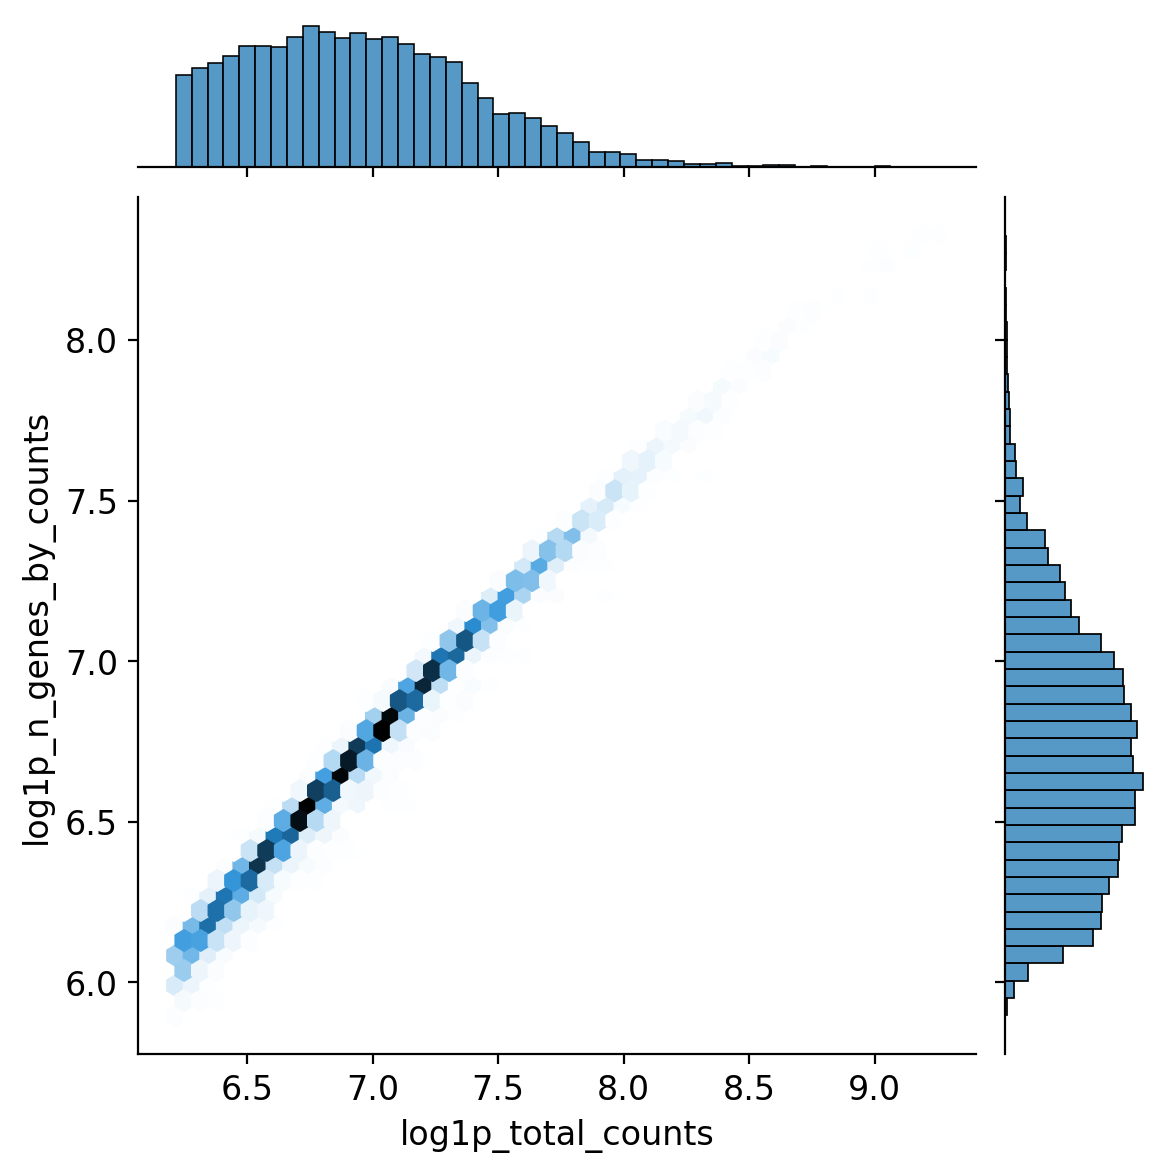

In [18]:
sns.jointplot(
    data=Oadata.obs,
    x="log1p_total_counts",
    y="log1p_n_genes_by_counts",
    kind="hex",
)

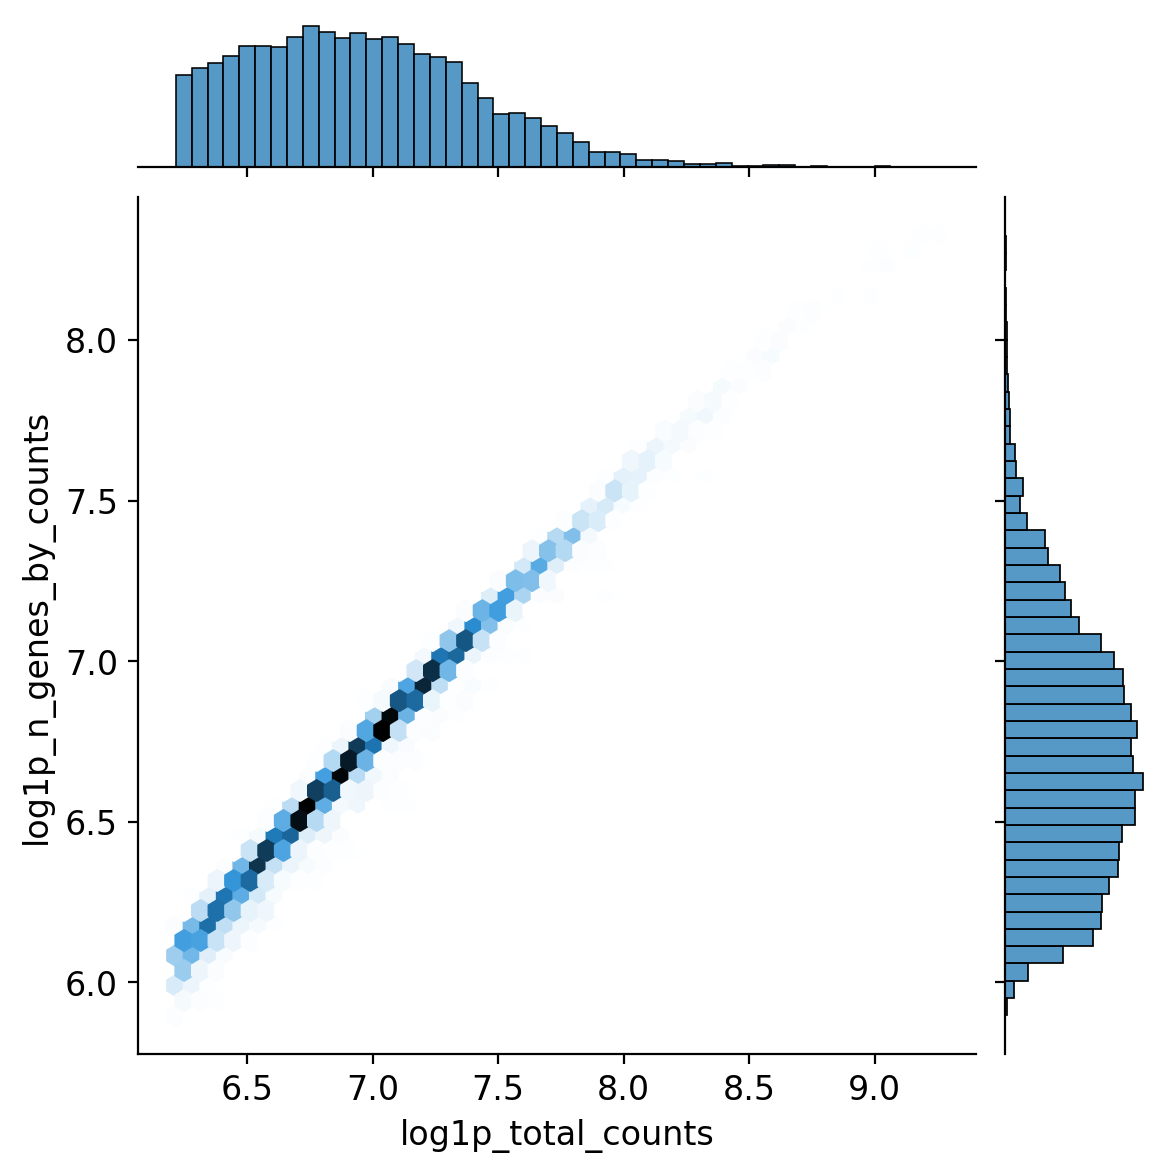

In [19]:
sns.jointplot(
    data=Tadata.obs,
    x="log1p_total_counts",
    y="log1p_n_genes_by_counts",
    kind="hex",
)

In [20]:
#adata.obs_names_make_unique()
sc.pp.normalize_per_cell(Oadata, counts_per_cell_after=1e4)
sc.pp.log1p(Oadata)

#Iadata.obs_names_make_unique()
sc.pp.normalize_per_cell(Tadata, counts_per_cell_after=1e4)
sc.pp.log1p(Tadata)

In [36]:
intersect = [t for t in Oadata.obs.index if t in Tadata.obs.index]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 290.6 kB/s eta 0:00:00a 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for matplotlib-venn: filename=matplotlib_venn-1.1.1-py3-none-any.whl size=45288 sha256=1713a8af5c8fb41fd16b4973007a59bb6d94bd87cd01c4a81497bc60ec475f28
  Stored in directory: /home/rebekah/.cache/pip/wheels/96/4b/f9/2666d92914c7a707c7b84e40cf53a80b8eb1ae1b46fcc171f0
Successfully built matplotlib-venn


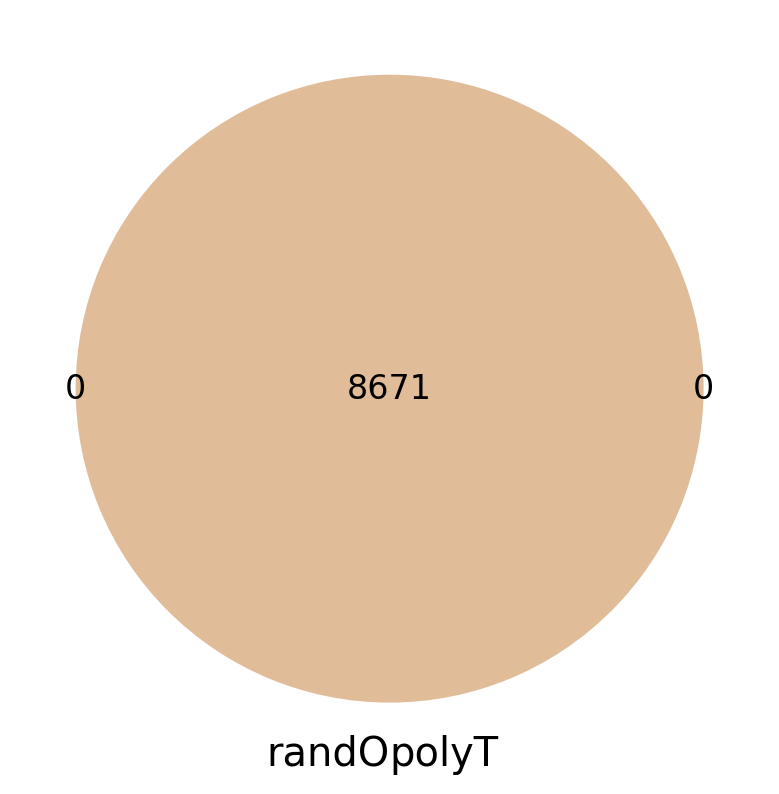

In [23]:
!pip install matplotlib-venn
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

tadata = [t for t in Tadata.obs["cell_identity"]]
oadata = [o for o in Oadata.obs["cell_identity"]]

venn2((set(oadata), set(tadata)), ('randO', 'polyT'))


In [24]:
intersect_g = [gene for gene in Oadata.var.index if gene in Tadata.var.index]

In [25]:
#intersect = set(tadata) & set(oadata)
print(len(intersect))
print(len(intersect_g))

8671
9902


In [ ]:
Tadata.var.index

In [29]:
pearson_gene_O_vs_T = []
for c in intersect:
    if np.squeeze(np.asarray(Oadata[c, intersect_g].X.todense())).all() != 1:
        pearson=scipy.stats.pearsonr(np.squeeze(np.asarray(Oadata[c, intersect_g].X.todense())), np.squeeze(np.asarray(Tadata[c, intersect_g].X.todense())))
        pearson_gene_O_vs_T.append(pearson[0])

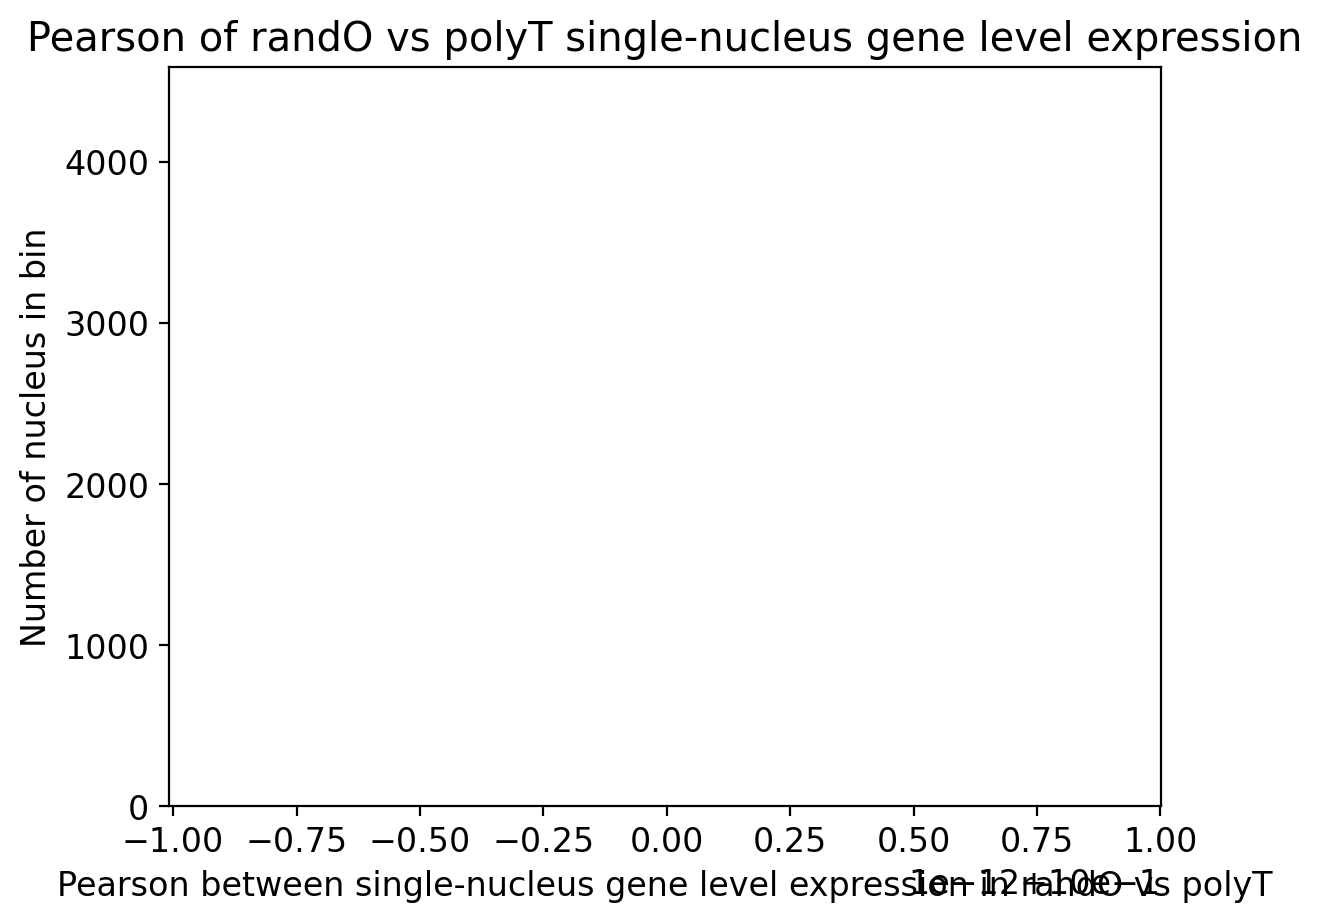

8671

In [30]:
import matplotlib.pyplot as plt

plt.hist(pearson_gene_O_vs_T, bins=100, color='C1')
plt.xlabel("Pearson between single-nucleus gene level expression in randO vs polyT")
plt.ylabel("Number of nucleus in bin")
plt.title("Pearson of randO vs polyT single-nucleus gene level expression")
plt.show()
len(pearson_gene_O_vs_T)

In [31]:
#Iadata.obs_names_make_unique(join='-')
spearman_gene_O_vs_T = []
for c in intersect:
    if np.squeeze(np.asarray(Oadata[c, intersect_g].X.todense())).all() != 1:
        spearman=scipy.stats.spearmanr(np.squeeze(np.asarray(Oadata[c, intersect_g].X.todense())), np.squeeze(np.asarray(Tadata[c, intersect_g].X.todense())))
        spearman_gene_O_vs_T.append(spearman[0])

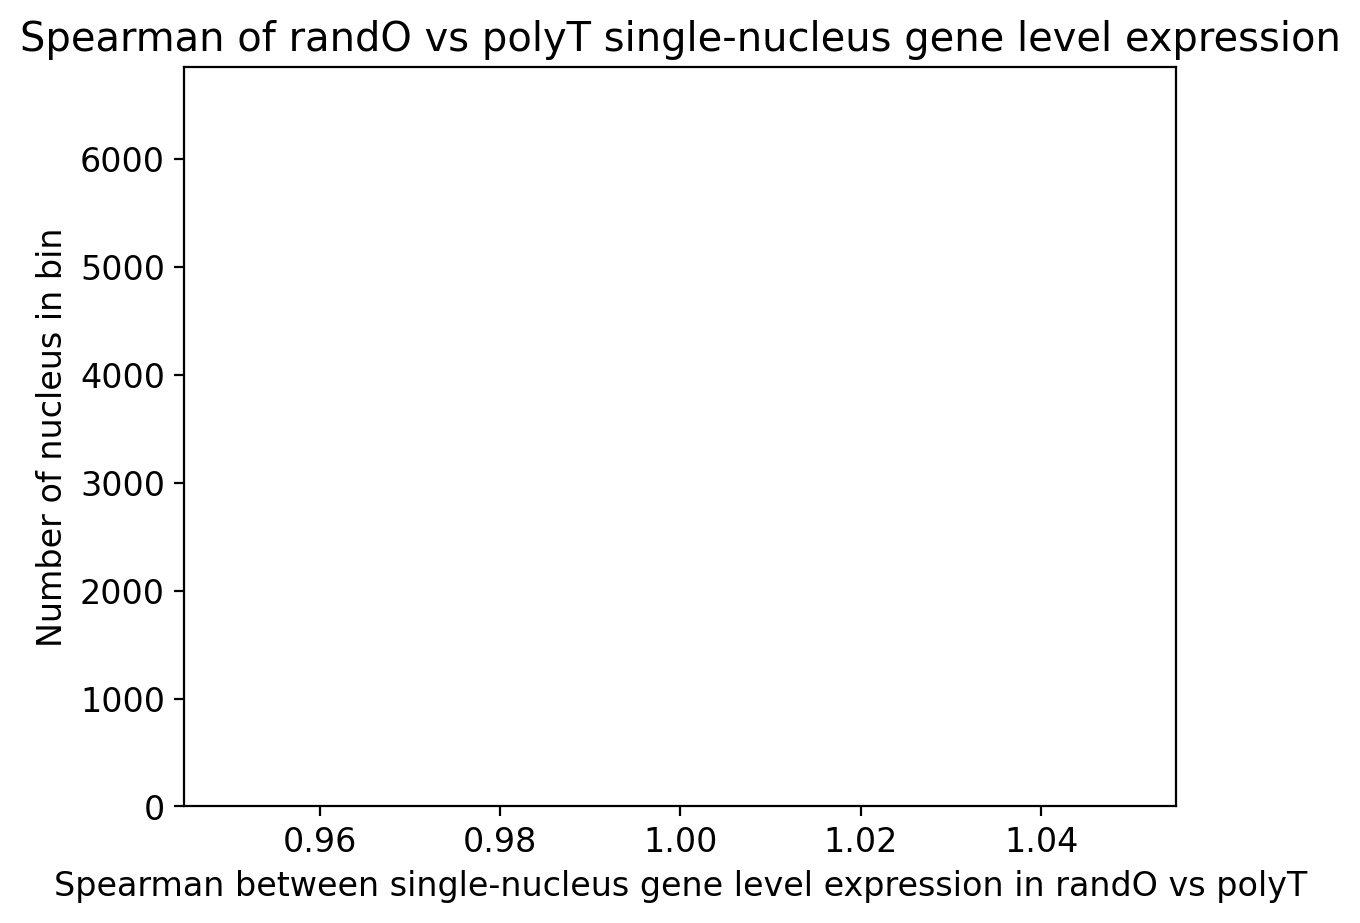

[0.9999999999999998, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9999999999999998, 1.0, 1.0, 1.0, 1.0, 0.9999999999999998, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9999999999999999, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9999999999999999, 1.0, 1.0, 1.0, 1.0, 0.9999999999999999, 0.9999999999999999, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9999999999999999, 1.0, 0.9999999999999998, 1.0, 0.9999999999999998, 1.0, 1.0, 0.9999999999999998, 1.0, 0.9999999999999998, 1.0, 1.0, 1.0, 0.9999999999999999, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9999999999999999, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9999999999999998, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9999999999999999, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9999999999999999, 0.9999999999999999, 0.9999999999999998, 0.9999999999999998, 0.9999999999999999, 0.9999999999999999, 0.9999999999999999, 0.9999999999999998, 0.9999999999999998, 1.0, 1.0, 1.0, 0.9999999999999998, 1.0, 1.0, 1.0, 1.0, 0.9999999

In [37]:
import matplotlib.pyplot as plt

plt.hist(spearman_gene_O_vs_T, bins=100, color='C1')
plt.xlabel("Spearman between single-nucleus gene level expression in randO vs polyT")
plt.ylabel("Number of nucleus in bin")
plt.title("Spearman of randO vs polyT single-nucleus gene level expression")
plt.show()
len(spearman_gene_O_vs_T)
print(spearman_gene_O_vs_T)

In [39]:
print(Oadata.X)

  (0, 11)	0.8783617
  (0, 18)	2.6146615
  (0, 29)	2.6146615
  (0, 42)	1.9921522
  (0, 52)	2.6146615
  (0, 59)	2.6146615
  (0, 72)	2.6146615
  (0, 89)	2.6146615
  (0, 121)	2.6146615
  (0, 137)	2.6146615
  (0, 146)	2.6146615
  (0, 168)	2.6146615
  (0, 174)	2.6146615
  (0, 185)	2.6146615
  (0, 224)	2.6146615
  (0, 227)	2.6146615
  (0, 253)	2.6146615
  (0, 260)	2.6146615
  (0, 266)	2.6146615
  (0, 286)	3.270526
  (0, 304)	3.270526
  (0, 305)	2.6146615
  (0, 318)	2.6146615
  (0, 326)	2.6146615
  (0, 336)	3.270526
  :	:
  (8670, 9589)	2.6275425
  (8670, 9602)	2.6275425
  (8670, 9621)	2.00416
  (8670, 9626)	2.6275425
  (8670, 9633)	2.6275425
  (8670, 9634)	2.00416
  (8670, 9636)	2.6275425
  (8670, 9652)	2.6275425
  (8670, 9675)	3.9581213
  (8670, 9682)	2.6275425
  (8670, 9688)	2.6275425
  (8670, 9704)	2.6275425
  (8670, 9723)	2.6275425
  (8670, 9738)	2.6275425
  (8670, 9739)	2.00416
  (8670, 9806)	2.6275425
  (8670, 9813)	2.6275425
  (8670, 9851)	2.6275425
  (8670, 9853)	3.283893
  (8670, 986

In [40]:
print(Tadata.X)

  (0, 11)	0.8783617
  (0, 18)	2.6146615
  (0, 29)	2.6146615
  (0, 42)	1.9921522
  (0, 52)	2.6146615
  (0, 59)	2.6146615
  (0, 72)	2.6146615
  (0, 89)	2.6146615
  (0, 121)	2.6146615
  (0, 137)	2.6146615
  (0, 146)	2.6146615
  (0, 168)	2.6146615
  (0, 174)	2.6146615
  (0, 185)	2.6146615
  (0, 224)	2.6146615
  (0, 227)	2.6146615
  (0, 253)	2.6146615
  (0, 260)	2.6146615
  (0, 266)	2.6146615
  (0, 286)	3.270526
  (0, 304)	3.270526
  (0, 305)	2.6146615
  (0, 318)	2.6146615
  (0, 326)	2.6146615
  (0, 336)	3.270526
  :	:
  (8670, 9589)	2.6275425
  (8670, 9602)	2.6275425
  (8670, 9621)	2.00416
  (8670, 9626)	2.6275425
  (8670, 9633)	2.6275425
  (8670, 9634)	2.00416
  (8670, 9636)	2.6275425
  (8670, 9652)	2.6275425
  (8670, 9675)	3.9581213
  (8670, 9682)	2.6275425
  (8670, 9688)	2.6275425
  (8670, 9704)	2.6275425
  (8670, 9723)	2.6275425
  (8670, 9738)	2.6275425
  (8670, 9739)	2.00416
  (8670, 9806)	2.6275425
  (8670, 9813)	2.6275425
  (8670, 9851)	2.6275425
  (8670, 9853)	3.283893
  (8670, 986

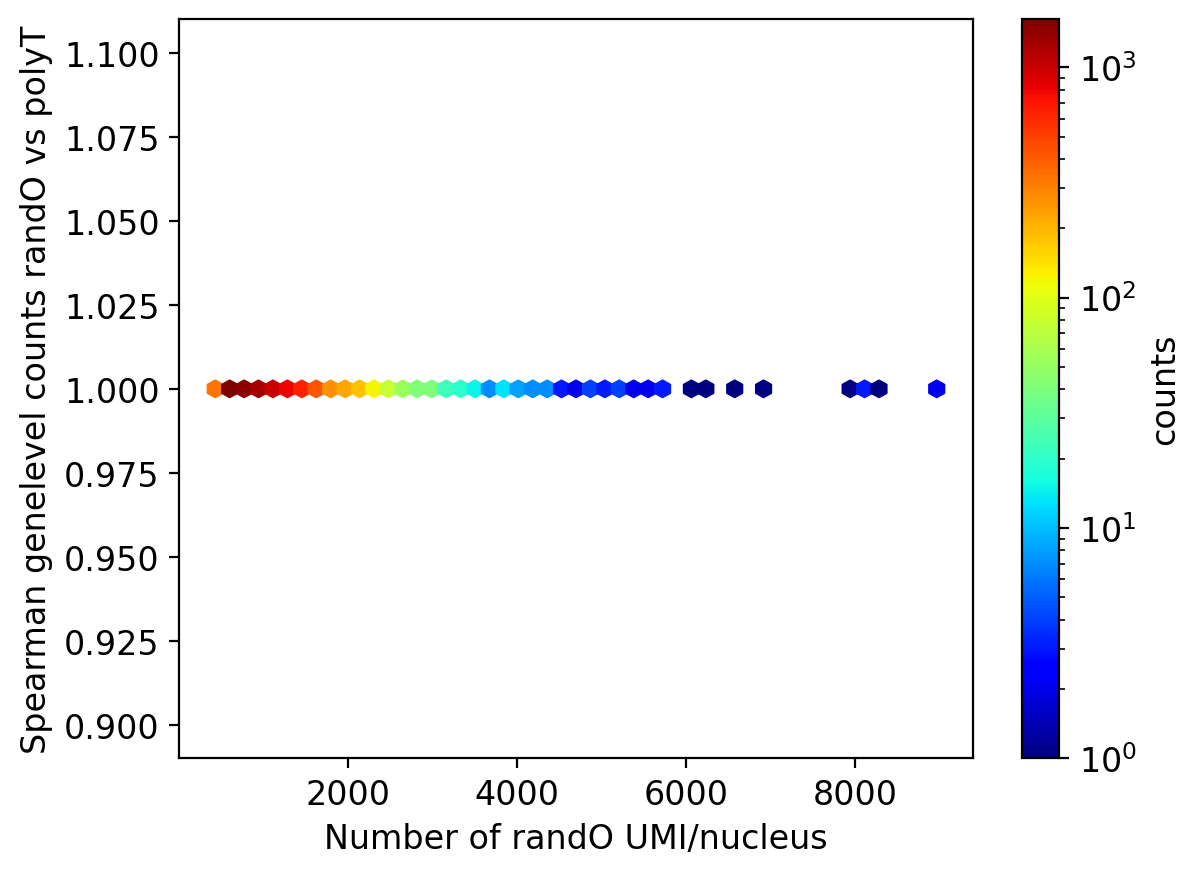

In [33]:
#plt.scatter(adata.obs['n_counts'], spearman_gene_ONT_vs_Ill)
plt.hexbin(Oadata.obs['n_counts'][intersect], spearman_gene_O_vs_T, gridsize=50, cmap='jet', bins='log')
plt.ylabel("Spearman genelevel counts randO vs polyT")
plt.xlabel("Number of randO UMI/nucleus")
plt.colorbar(label='counts')
plt.show()

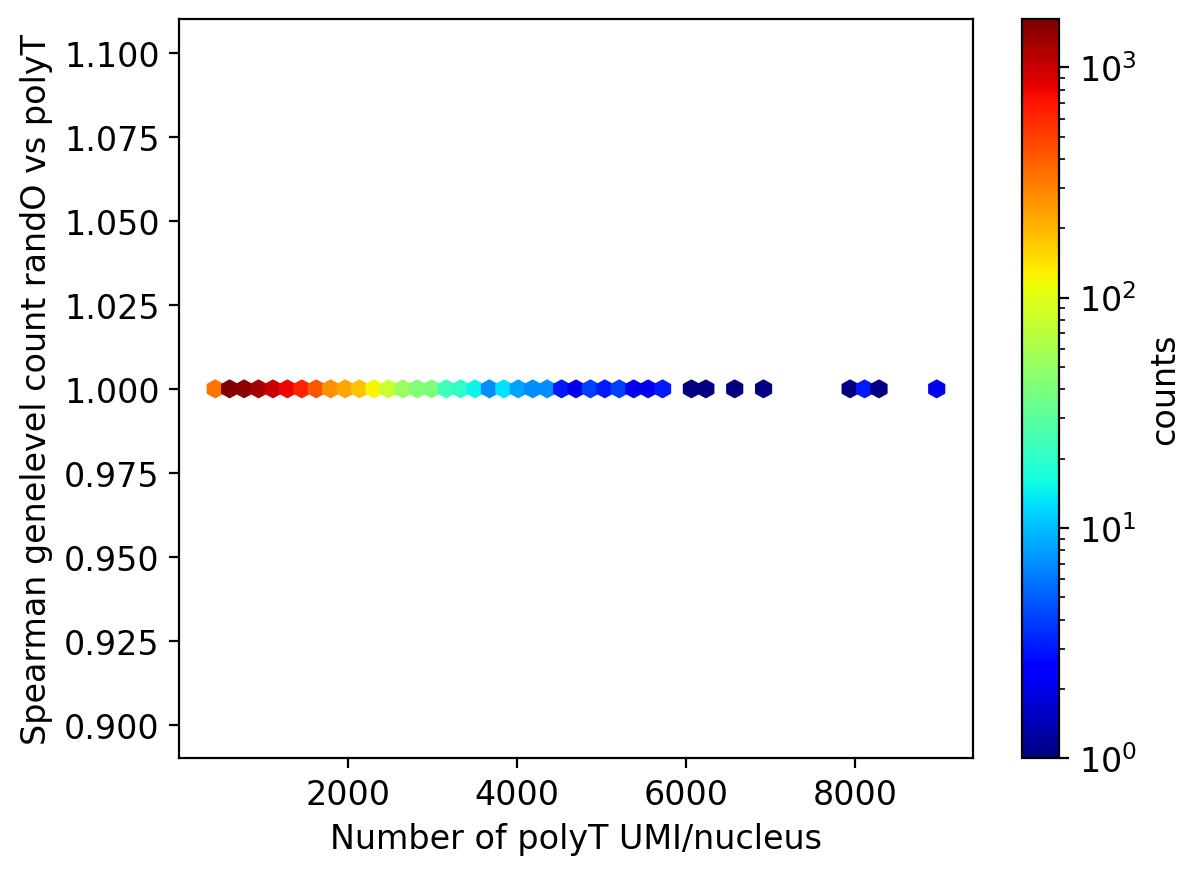

In [34]:
#plt.scatter(adata.obs['n_counts'], spearman_gene_ONT_vs_Ill)
plt.hexbin(Tadata.obs['n_counts'][intersect], spearman_gene_O_vs_T, gridsize=50, cmap='jet', bins='log')
plt.ylabel("Spearman genelevel count randO vs polyT")
plt.xlabel("Number of polyT UMI/nucleus")
plt.colorbar(label='counts')
plt.show()

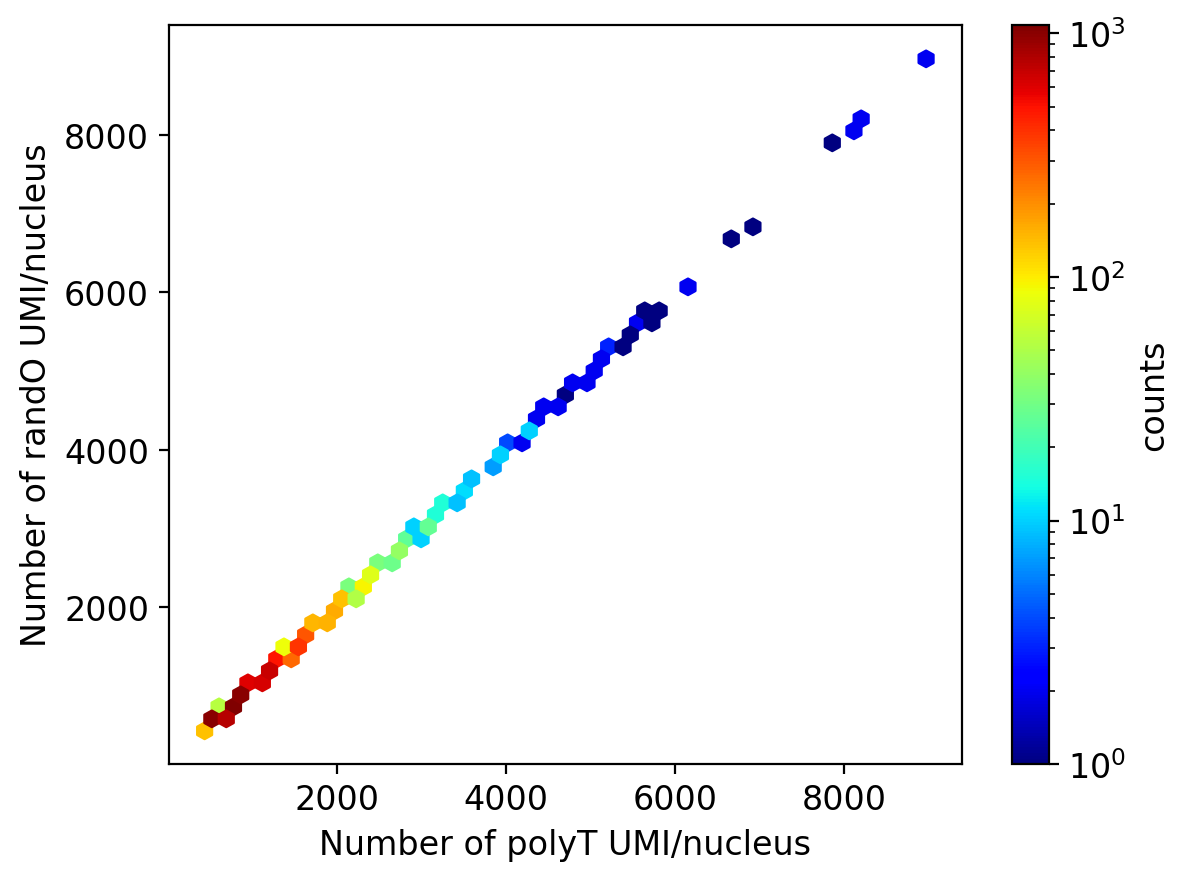

In [35]:
#plt.scatter(adata.obs['n_counts'], spearman_gene_ONT_vs_Ill)
plt.hexbin(Oadata.obs['n_counts'][intersect], Tadata.obs['n_counts'][intersect], gridsize=50, cmap='jet', bins='log')
plt.ylabel("Number of randO UMI/nucleus")
plt.xlabel("Number of polyT UMI/nucleus")
plt.colorbar(label='counts')
plt.show()

In [ ]:
Oadata.obs.index